In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 2ab22ca Add classification results for all 5 transform strategies


# NB3: Linear Probes for Legibility (Experiments A1 + B)

**CPU notebook** (~15 min). Trains linear probes on pre-extracted activations.

**Experiment A1** -- Per-layer probes:
- (a) Answer probe: predict correct answer letter from last-token activations
- (b) Legibility probe: predict REASONING_LEGIBLE vs ILLEGIBLE
- Compare AUROC across layers, include foreignness covariate

**Experiment B** -- Pre-CoT illegibility predictor:
- Binary probe on question-token activations (before `<think>`)
- 5-fold stratified CV with bootstrap CIs
- Key result: if AUROC > 0.65, illegibility is predictable before generation

**Requires:** NB1 outputs (`activations/{G1,G3}_last_token/`, `activations/{G1,G3}_question_token/`)

In [2]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_phase1_results, get_labeled_cots, join_cots_with_labels,
    load_foreignness_scores, load_activations, train_binary_probe,
    permutation_test, plot_layer_probe_curve, plot_comparison_curves,
    bootstrap_ci_metric, print_phase1_summary,
    ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print_phase1_summary()

Total records: 1285
Classified: 666, Filtered: 619
R4 transform: _t64
Label counts:
  ANSWER_LEAKED: 278
  FILTERED: 619
  ILLEGIBLE: 288
  REASONING_LEGIBLE: 100

Per-generator:
  G1: 219 classified (leaked=25%, legible=15%, illegible=60%)
  G2: 218 classified (leaked=69%, legible=17%, illegible=14%)
  G3: 229 classified (leaked=32%, legible=13%, illegible=55%)
  G1 within-Q pairs: 0
  G3 within-Q pairs: 0


In [3]:
# Checkpoint: check if final output already exists
_output_path = PHASE2_RESULTS_DIR / 'probe_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    print(f"CACHED: {_output_path} exists with {len(_saved)} experiment groups.")
    for key in _saved:
        print(f"  {key}: {list(_saved[key].keys()) if isinstance(_saved[key], dict) else 'present'}")
    print("Delete this file and re-run to recompute.")

CACHED: /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/probe_results.json exists with 2 experiment groups.
  exp_a1b_legibility: ['G3', 'G1']
  exp_a1a_answer: ['G3']
Delete this file and re-run to recompute.


In [4]:
# Load pre-extracted activations and their metadata
g3_last = load_activations(ACTIVATIONS_DIR / "G3_last_token")
g1_last = load_activations(ACTIVATIONS_DIR / "G1_last_token")
g3_question = load_activations(ACTIVATIONS_DIR / "G3_question_token")
g1_question = load_activations(ACTIVATIONS_DIR / "G1_question_token")

# Load metadata to get sample ordering and labels
with open(ACTIVATIONS_DIR / "G3_last_token" / "metadata.json") as f:
    g3_meta = json.load(f)
with open(ACTIVATIONS_DIR / "G1_last_token" / "metadata.json") as f:
    g1_meta = json.load(f)

# Extract labels from metadata (sample_ids contains tuples of (sid, gid, epoch, label))
g3_labels = [s[3] for s in g3_meta['sample_ids']]
g1_labels = [s[3] for s in g1_meta['sample_ids']]

print(f"G3 activations: {len(g3_labels)} samples, layers={sorted(g3_last.keys())}")
print(f"G1 activations: {len(g1_labels)} samples, layers={sorted(g1_last.keys())}")
print(f"G3 label dist: {dict(Counter(g3_labels))}")
print(f"G1 label dist: {dict(Counter(g1_labels))}")

G3 activations: 229 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 63]
G1 activations: 219 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 63]
G3 label dist: {'ILLEGIBLE': 126, 'ANSWER_LEAKED': 73, 'REASONING_LEGIBLE': 30}
G1 label dist: {'ILLEGIBLE': 131, 'REASONING_LEGIBLE': 33, 'ANSWER_LEAKED': 55}


## Experiment A1(b): Legibility Probe

Binary classification: REASONING_LEGIBLE (1) vs ILLEGIBLE (0) from last-token activations.

In [5]:
# Build binary labels for legibility: REASONING_LEGIBLE=1, ILLEGIBLE=0
# Exclude ANSWER_LEAKED samples
def build_legibility_labels(label_list):
    """Return (mask, binary_labels) for legible vs illegible."""
    mask = []
    labels = []
    for l in label_list:
        if l == 'REASONING_LEGIBLE':
            mask.append(True)
            labels.append(1)
        elif l == 'ILLEGIBLE':
            mask.append(True)
            labels.append(0)
        else:
            mask.append(False)
            labels.append(-1)
    return np.array(mask), np.array(labels)

g3_mask, g3_binary = build_legibility_labels(g3_labels)
g1_mask, g1_binary = build_legibility_labels(g1_labels)

print(f"G3: {g3_mask.sum()} legible/illegible samples ({(g3_binary[g3_mask]==1).sum()} legible, {(g3_binary[g3_mask]==0).sum()} illegible)")
print(f"G1: {g1_mask.sum()} legible/illegible samples ({(g1_binary[g1_mask]==1).sum()} legible, {(g1_binary[g1_mask]==0).sum()} illegible)")

G3: 156 legible/illegible samples (30 legible, 126 illegible)
G1: 164 legible/illegible samples (33 legible, 131 illegible)


In [6]:
# Train per-layer legibility probes for G3
g3_legibility_results = {}

for layer_idx in sorted(g3_last.keys()):
    features = g3_last[layer_idx][g3_mask]
    labels = g3_binary[g3_mask]
    
    result = train_binary_probe(features, labels, n_splits=5)
    g3_legibility_results[layer_idx] = result
    print(f"  G3 Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} "
          f"CI=[{result['auroc_ci'][0]:.3f}, {result['auroc_ci'][1]:.3f}] "
          f"n={result['n_samples']}")

  G3 Layer   0: AUROC=0.520 CI=[0.424, 0.583] n=156
  G3 Layer   4: AUROC=0.510 CI=[0.480, 0.541] n=156
  G3 Layer   8: AUROC=0.548 CI=[0.490, 0.625] n=156
  G3 Layer  12: AUROC=0.510 CI=[0.407, 0.604] n=156
  G3 Layer  16: AUROC=0.473 CI=[0.391, 0.547] n=156
  G3 Layer  20: AUROC=0.472 CI=[0.380, 0.552] n=156
  G3 Layer  24: AUROC=0.493 CI=[0.432, 0.551] n=156
  G3 Layer  28: AUROC=0.485 CI=[0.385, 0.580] n=156
  G3 Layer  32: AUROC=0.488 CI=[0.404, 0.561] n=156
  G3 Layer  36: AUROC=0.488 CI=[0.397, 0.598] n=156
  G3 Layer  40: AUROC=0.539 CI=[0.472, 0.606] n=156
  G3 Layer  44: AUROC=0.560 CI=[0.460, 0.645] n=156
  G3 Layer  48: AUROC=0.611 CI=[0.549, 0.675] n=156
  G3 Layer  52: AUROC=0.561 CI=[0.503, 0.626] n=156
  G3 Layer  56: AUROC=0.563 CI=[0.472, 0.643] n=156
  G3 Layer  60: AUROC=0.549 CI=[0.423, 0.668] n=156
  G3 Layer  63: AUROC=0.492 CI=[0.379, 0.592] n=156


In [7]:
# Train per-layer legibility probes for G1
g1_legibility_results = {}

for layer_idx in sorted(g1_last.keys()):
    features = g1_last[layer_idx][g1_mask]
    labels = g1_binary[g1_mask]
    
    result = train_binary_probe(features, labels, n_splits=5)
    g1_legibility_results[layer_idx] = result
    print(f"  G1 Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} "
          f"CI=[{result['auroc_ci'][0]:.3f}, {result['auroc_ci'][1]:.3f}]")

  G1 Layer   0: AUROC=0.527 CI=[0.455, 0.596]
  G1 Layer   4: AUROC=0.585 CI=[0.475, 0.710]
  G1 Layer   8: AUROC=0.644 CI=[0.556, 0.731]
  G1 Layer  12: AUROC=0.602 CI=[0.524, 0.683]
  G1 Layer  16: AUROC=0.594 CI=[0.507, 0.681]
  G1 Layer  20: AUROC=0.612 CI=[0.547, 0.658]
  G1 Layer  24: AUROC=0.600 CI=[0.494, 0.671]
  G1 Layer  28: AUROC=0.609 CI=[0.524, 0.692]
  G1 Layer  32: AUROC=0.627 CI=[0.565, 0.686]
  G1 Layer  36: AUROC=0.618 CI=[0.553, 0.674]
  G1 Layer  40: AUROC=0.608 CI=[0.530, 0.695]
  G1 Layer  44: AUROC=0.594 CI=[0.520, 0.654]
  G1 Layer  48: AUROC=0.629 CI=[0.570, 0.693]
  G1 Layer  52: AUROC=0.609 CI=[0.556, 0.661]
  G1 Layer  56: AUROC=0.562 CI=[0.499, 0.638]
  G1 Layer  60: AUROC=0.534 CI=[0.470, 0.605]
  G1 Layer  63: AUROC=0.545 CI=[0.481, 0.610]


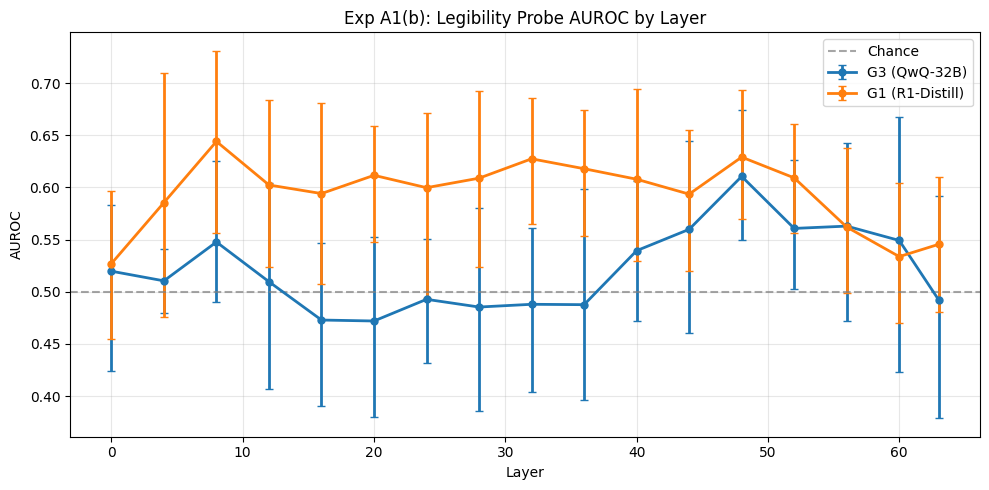

In [8]:
# Plot comparison: G1 vs G3 legibility probes
fig, ax = plot_comparison_curves(
    {"G3 (QwQ-32B)": g3_legibility_results, "G1 (R1-Distill)": g1_legibility_results},
    title="Exp A1(b): Legibility Probe AUROC by Layer",
    save_path=str(PHASE2_RESULTS_DIR / "a1b_legibility_probe.png"),
)
plt.show()

In [9]:
# Permutation test on best layer for each model
for name, results_dict, last_acts, mask, binary in [
    ("G3", g3_legibility_results, g3_last, g3_mask, g3_binary),
    ("G1", g1_legibility_results, g1_last, g1_mask, g1_binary),
]:
    best_layer = max(results_dict, key=lambda k: results_dict[k]['auroc'])
    features = last_acts[best_layer][mask]
    labels = binary[mask]
    
    perm = permutation_test(features, labels, n_permutations=1000)
    print(f"{name} best layer={best_layer}: observed={perm['observed_auroc']:.3f}, "
          f"null={perm['null_mean']:.3f}+/-{perm['null_std']:.3f}, p={perm['p_value']:.4f}")

KeyboardInterrupt: 

## Experiment A1(a): Answer Probe

Predict the correct answer from last-token activations. Hypothesis: answer probes
may succeed on both legible and illegible CoTs (the model computed the answer
regardless of whether it's legible to readers).

In [10]:
# For answer probes, we need to encode the target answer.
# For MCQA: target is a letter (A-E) -> encode as integer.
# For open-ended math: skip (too many unique answers for a simple probe).

results = load_phase1_results()
cots_g3 = join_cots_with_labels(generator_ids=["G3"])
cots_g3 = sorted(cots_g3, key=lambda x: (x['sample_id'], x['epoch']))

# Build answer labels for MCQA samples only
g3_answer_mask = []
g3_answer_labels = []
for c in cots_g3:
    is_mcqa = c.get('cot_metadata', {}).get('task_type') == 'multiple_choice'
    if is_mcqa and c['target'] in 'ABCDE':
        g3_answer_mask.append(True)
        g3_answer_labels.append(ord(c['target']) - ord('A'))
    else:
        g3_answer_mask.append(False)
        g3_answer_labels.append(-1)

g3_answer_mask = np.array(g3_answer_mask)
g3_answer_labels = np.array(g3_answer_labels)
print(f"MCQA samples for answer probe: {g3_answer_mask.sum()}")
print(f"Answer distribution: {dict(Counter(g3_answer_labels[g3_answer_mask]))}")

MCQA samples for answer probe: 38
Answer distribution: {np.int64(1): 9, np.int64(3): 10, np.int64(2): 13, np.int64(0): 6}


In [11]:
# Train answer probes (multi-class) at each layer
# Use Pipeline to avoid scaler data leakage
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

g3_answer_results = {}
for layer_idx in sorted(g3_last.keys()):
    features = g3_last[layer_idx][g3_answer_mask]
    labels = g3_answer_labels[g3_answer_mask]
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('probe', LogisticRegression(max_iter=1000, random_state=42)),
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Use accuracy for multi-class (not AUROC)
    cv_scores = cross_val_score(pipeline, features, labels, cv=cv, scoring='accuracy')
    
    g3_answer_results[layer_idx] = {
        'accuracy': float(np.mean(cv_scores)),
        'accuracy_std': float(np.std(cv_scores)),
        'auroc': float(np.mean(cv_scores)),  # for plotting compatibility
        'auroc_ci': (float(np.mean(cv_scores) - 1.96*np.std(cv_scores)),
                     float(np.mean(cv_scores) + 1.96*np.std(cv_scores))),
    }
    print(f"  G3 Layer {layer_idx:3d}: Acc={np.mean(cv_scores):.3f} +/- {np.std(cv_scores):.3f}")

# Chance level for 4-choice MCQA
print(f"\nChance level: {1.0/len(set(g3_answer_labels[g3_answer_mask])):.3f}")

  G3 Layer   0: Acc=0.339 +/- 0.044
  G3 Layer   4: Acc=0.314 +/- 0.131
  G3 Layer   8: Acc=0.289 +/- 0.151
  G3 Layer  12: Acc=0.257 +/- 0.159
  G3 Layer  16: Acc=0.157 +/- 0.102
  G3 Layer  20: Acc=0.239 +/- 0.099
  G3 Layer  24: Acc=0.296 +/- 0.117
  G3 Layer  28: Acc=0.293 +/- 0.105
  G3 Layer  32: Acc=0.368 +/- 0.091
  G3 Layer  36: Acc=0.368 +/- 0.046
  G3 Layer  40: Acc=0.211 +/- 0.129
  G3 Layer  44: Acc=0.214 +/- 0.117
  G3 Layer  48: Acc=0.264 +/- 0.092
  G3 Layer  52: Acc=0.314 +/- 0.123
  G3 Layer  56: Acc=0.286 +/- 0.142
  G3 Layer  60: Acc=0.286 +/- 0.142
  G3 Layer  63: Acc=0.286 +/- 0.142

Chance level: 0.250


In [12]:
# Split answer probe by legibility class
# Does the answer probe work equally well on legible vs illegible CoTs?
# Use Pipeline to avoid scaler data leakage
g3_leg_labels_all = [s[3] for s in g3_meta['sample_ids']]

for legibility_class in ['REASONING_LEGIBLE', 'ILLEGIBLE']:
    class_mask = np.array([
        g3_answer_mask[i] and g3_leg_labels_all[i] == legibility_class
        for i in range(len(g3_leg_labels_all))
    ])
    if class_mask.sum() < 10:
        print(f"  {legibility_class}: only {class_mask.sum()} MCQA samples, skipping")
        continue
    
    # Use best layer from overall answer probe
    best_layer = max(g3_answer_results, key=lambda k: g3_answer_results[k]['accuracy'])
    features = g3_last[best_layer][class_mask]
    labels = g3_answer_labels[class_mask]
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('probe', LogisticRegression(max_iter=1000, random_state=42)),
    ])
    
    if len(set(labels)) > 1:
        cv = StratifiedKFold(n_splits=min(5, class_mask.sum() // 3), shuffle=True, random_state=42)
        cv_scores = cross_val_score(pipeline, features, labels, cv=cv, scoring='accuracy')
        print(f"  {legibility_class} (layer {best_layer}): Acc={np.mean(cv_scores):.3f} n={class_mask.sum()}")
    else:
        print(f"  {legibility_class}: only 1 class in answers, skipping")

  REASONING_LEGIBLE: only 4 MCQA samples, skipping


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


  ILLEGIBLE (layer 32): Acc=0.230 n=21


## Experiment B: Pre-CoT Illegibility Prediction

Can we predict whether a CoT will be legible or illegible from the question-token
activations (before `<think>`)? If AUROC > 0.65, illegibility is predictable
before generation and could be used as a generation-time monitor.

In [ ]:
# Train pre-CoT legibility probes
print("=== Experiment B: Pre-CoT Illegibility Prediction ===")

for name, q_acts, mask, binary in [
    ("G3", g3_question, g3_mask, g3_binary),
    ("G1", g1_question, g1_mask, g1_binary),
]:
    print(f"\n--- {name} ---")
    best_auroc = 0
    best_layer = None
    
    for layer_idx in sorted(q_acts.keys()):
        features = q_acts[layer_idx][mask]
        labels = binary[mask]
        
        if len(features) < 10:
            print(f"  Layer {layer_idx}: insufficient samples ({len(features)})")
            continue
        
        result = train_binary_probe(features, labels, n_splits=5)
        print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")
        
        if result['auroc'] > best_auroc:
            best_auroc = result['auroc']
            best_layer = layer_idx
    
    print(f"\n  Best: layer {best_layer}, AUROC={best_auroc:.3f}")
    
    # Permutation test on best layer (1000 permutations for stable p-values)
    features = q_acts[best_layer][mask]
    labels = binary[mask]
    perm = permutation_test(features, labels, n_permutations=1000)
    print(f"  Permutation test: observed={perm['observed_auroc']:.3f}, "
          f"null={perm['null_mean']:.3f}, p={perm['p_value']:.4f}")
    
    # Key finding
    if best_auroc > 0.65:
        print(f"  >> RESULT: Illegibility IS predictable before generation (AUROC={best_auroc:.3f} > 0.65)")
    else:
        print(f"  >> RESULT: Illegibility NOT clearly predictable before generation (AUROC={best_auroc:.3f})")

=== Experiment B: Pre-CoT Illegibility Prediction ===

--- G3 ---
  Layer   0: AUROC=0.718 CI=(0.589974358974359, 0.8366666666666667)
  Layer   4: AUROC=0.680 CI=(0.5399294871794872, 0.8211794871794872)
  Layer   8: AUROC=0.593 CI=(0.45599999999999996, 0.6923564102564101)
  Layer  12: AUROC=0.595 CI=(0.41748717948717945, 0.7201538461538461)
  Layer  16: AUROC=0.626 CI=(0.4066333333333333, 0.7511794871794872)
  Layer  20: AUROC=0.633 CI=(0.46266666666666667, 0.7493333333333333)
  Layer  24: AUROC=0.700 CI=(0.5370333333333336, 0.8213333333333332)
  Layer  28: AUROC=0.757 CI=(0.5906179487179488, 0.8933666666666666)
  Layer  32: AUROC=0.717 CI=(0.5531076923076925, 0.8534333333333332)
  Layer  36: AUROC=0.672 CI=(0.536, 0.8)
  Layer  40: AUROC=0.680 CI=(0.5661782051282056, 0.7906666666666666)
  Layer  44: AUROC=0.670 CI=(0.5567179487179488, 0.7733333333333334)
  Layer  48: AUROC=0.691 CI=(0.6039076923076924, 0.7773333333333333)
  Layer  52: AUROC=0.713 CI=(0.6359000000000001, 0.783487179487

## Foreignness Covariate Analysis

Report probe AUROC with and without foreignness to isolate distributional shift from content.

In [25]:
# Load foreignness scores and add as a covariate
foreignness = load_foreignness_scores()
print(f"Loaded {len(foreignness)} foreignness scores")

# For each G3 sample, get mean foreignness across readers
cots_g3_sorted = sorted(join_cots_with_labels(generator_ids=['G3']),
                        key=lambda x: (x['sample_id'], x['epoch']))

g3_foreignness = []
for c in cots_g3_sorted:
    scores = []
    for rid in ['R1', 'R2', 'R3']:
        key = (c['sample_id'], c['generator_id'], c['epoch'], rid)
        if key in foreignness:
            scores.append(foreignness[key])
    g3_foreignness.append(np.mean(scores) if scores else np.nan)
g3_foreignness = np.array(g3_foreignness)

print(f"Foreignness available for {np.isfinite(g3_foreignness).sum()}/{len(g3_foreignness)} samples")
print(f"Mean foreignness: legible={g3_foreignness[g3_mask & (g3_binary==1)].mean():.2f}, "
      f"illegible={g3_foreignness[g3_mask & (g3_binary==0)].mean():.2f}")

Loaded 4545 foreignness scores
Foreignness available for 101/101 samples
Mean foreignness: legible=2.04, illegible=1.96


In [26]:
# Compare: probe with vs without foreignness covariate
best_layer_g3 = max(g3_legibility_results, key=lambda k: g3_legibility_results[k]['auroc'])
features_base = g3_last[best_layer_g3][g3_mask]
labels = g3_binary[g3_mask]
foreignness_subset = g3_foreignness[g3_mask]

# Valid foreignness mask
valid_f = np.isfinite(foreignness_subset)

if valid_f.sum() > 20:
    # Without foreignness
    result_no_f = train_binary_probe(features_base[valid_f], labels[valid_f])
    print(f"Without foreignness: AUROC={result_no_f['auroc']:.3f} CI={result_no_f['auroc_ci']}")
    
    # With foreignness as additional feature
    features_with_f = np.column_stack([features_base[valid_f], foreignness_subset[valid_f].reshape(-1, 1)])
    result_with_f = train_binary_probe(features_with_f, labels[valid_f])
    print(f"With foreignness:    AUROC={result_with_f['auroc']:.3f} CI={result_with_f['auroc_ci']}")
    
    # Foreignness-only probe
    result_f_only = train_binary_probe(foreignness_subset[valid_f].reshape(-1, 1), labels[valid_f])
    print(f"Foreignness only:    AUROC={result_f_only['auroc']:.3f} CI={result_f_only['auroc_ci']}")
else:
    print(f"Only {valid_f.sum()} samples with foreignness scores, skipping covariate analysis")

Without foreignness: AUROC=0.674 CI=(0.5503500000000002, 0.798)
With foreignness:    AUROC=0.674 CI=(0.5503500000000002, 0.798)
Foreignness only:    AUROC=0.589 CI=(0.43866666666666665, 0.6890000000000001)


In [ ]:
# Save all probe results (including Experiment B)
def serialize_probe_results(results_dict):
    """Remove non-serializable objects (sklearn models) for JSON."""
    clean = {}
    for layer_idx, r in results_dict.items():
        clean[int(layer_idx)] = {
            k: v for k, v in r.items()
            if k not in ('probe_model', 'scaler', 'pipeline')
        }
    return clean

# Collect Experiment B results by re-running best-layer summary
# (the probes were already trained in the exp_b_probes cell)
exp_b_results = {}
for name, q_acts, mask, binary in [
    ("G3", g3_question, g3_mask, g3_binary),
    ("G1", g1_question, g1_mask, g1_binary),
]:
    layer_results = {}
    best_auroc = 0
    best_layer = None
    for layer_idx in sorted(q_acts.keys()):
        features = q_acts[layer_idx][mask]
        labels = binary[mask]
        if len(features) < 10:
            continue
        result = train_binary_probe(features, labels, n_splits=5)
        layer_results[layer_idx] = result
        if result['auroc'] > best_auroc:
            best_auroc = result['auroc']
            best_layer = layer_idx

    # Permutation test on best layer
    perm_result = None
    if best_layer is not None:
        features = q_acts[best_layer][mask]
        labels = binary[mask]
        perm_result = permutation_test(features, labels, n_permutations=1000)

    exp_b_results[name] = {
        'layer_results': serialize_probe_results(layer_results),
        'best_layer': best_layer,
        'best_auroc': best_auroc,
        'permutation_test': perm_result,
    }

output = {
    'exp_a1b_legibility': {
        'G3': serialize_probe_results(g3_legibility_results),
        'G1': serialize_probe_results(g1_legibility_results),
    },
    'exp_a1a_answer': {
        'G3': serialize_probe_results(g3_answer_results),
    },
    'exp_b_pre_cot': exp_b_results,
}

with open(PHASE2_RESULTS_DIR / 'probe_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Results saved to {PHASE2_RESULTS_DIR / 'probe_results.json'}")
print(f"  Includes: {list(output.keys())}")
for model_name, data in exp_b_results.items():
    perm = data.get('permutation_test', {})
    p_val = perm.get('p_value', 'N/A') if perm else 'N/A'
    print(f"  Exp B {model_name}: best_layer={data['best_layer']}, "
          f"AUROC={data['best_auroc']:.3f}, p={p_val}")